# Time's Hub vs Meta Robyn — MMM Karşılaştırma Analizi

Bu notebook, Time's Hub MMM engine ile Meta Robyn'in yaklaşımlarını **PO Filo kampanyası** verileri üzerinde karşılaştırır.

| Boyut | Time's Hub | Robyn |
|-------|-----------|-------|
| Adstock | Geometric decay | Geometric + Weibull |
| Saturation | Hill function | Hill function |
| Trend/Seasonality | Yok (kısa kampanya) | Prophet decomposition |
| Regresyon | Deterministik response model | Ridge regression |
| Optimizasyon | Manuel parametreler | Nevergrad multi-objective |
| Offline | GRP-based pipeline | GRP desteği sınırlı |

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

from backend.models.mmm import compute_adstock, compute_saturation, compute_response
from backend.config import (
    ADSTOCK_PARAMS, SATURATION_PARAMS, MAX_LIFT,
    BASELINE_LEADS, CHANNELS
)

np.random.seed(42)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

## 1. Sentetik Kampanya Verisi (12 Hafta)

PO Filo kampanyasına benzer haftalık harcama verisi üretiyoruz.

In [2]:
WEEKS = 12

# Haftalık bütçe dağılımı (front-loaded kampanya)
weekly_budgets = {
    'meta':     [2_600_000, 2_800_000, 2_500_000, 2_200_000, 2_000_000,
                 1_800_000, 1_500_000, 1_200_000, 1_000_000, 800_000, 600_000, 400_000],
    'google':   [300_000, 320_000, 310_000, 290_000, 280_000,
                 260_000, 250_000, 240_000, 230_000, 220_000, 210_000, 200_000],
    'tiktok':   [500_000, 550_000, 480_000, 420_000, 380_000,
                 350_000, 300_000, 250_000, 200_000, 150_000, 100_000, 80_000],
    'linkedin': [200_000, 220_000, 210_000, 190_000, 180_000,
                 170_000, 160_000, 150_000, 140_000, 130_000, 120_000, 110_000],
    'youtube':  [400_000, 450_000, 420_000, 380_000, 350_000,
                 320_000, 280_000, 250_000, 220_000, 200_000, 180_000, 150_000],
    'tv_match': [800_000, 900_000, 850_000, 750_000, 700_000,
                 600_000, 500_000, 400_000, 350_000, 300_000, 250_000, 200_000],
}

# Gerçek lead verisini simüle et (gürültülü)
np.random.seed(42)
true_leads = []
for w in range(WEEKS):
    total = BASELINE_LEADS
    for ch, spends in weekly_budgets.items():
        decay = ADSTOCK_PARAMS[ch]
        alpha, gamma = SATURATION_PARAMS[ch]
        adstocked = compute_adstock(spends[:w+1], decay)
        sat = compute_saturation(adstocked[-1], alpha, gamma)
        total += MAX_LIFT[ch] * sat
    true_leads.append(total + np.random.normal(0, total * 0.05))

true_leads = np.array(true_leads)
print(f"Toplam {WEEKS} hafta, toplam lead: {true_leads.sum():.0f}")
print(f"Haftalık ortalama: {true_leads.mean():.0f}, min: {true_leads.min():.0f}, max: {true_leads.max():.0f}")

Toplam 12 hafta, toplam lead: 19644
Haftalık ortalama: 1637, min: 1027, max: 2059


## 2. Adstock Karşılaştırması: Geometric vs Weibull

Robyn hem **geometric** hem de **Weibull** (CDF/PDF) adstock destekler.
Weibull, gecikmeli zirve (delayed peak) modelleyebilir — TV için daha gerçekçi.

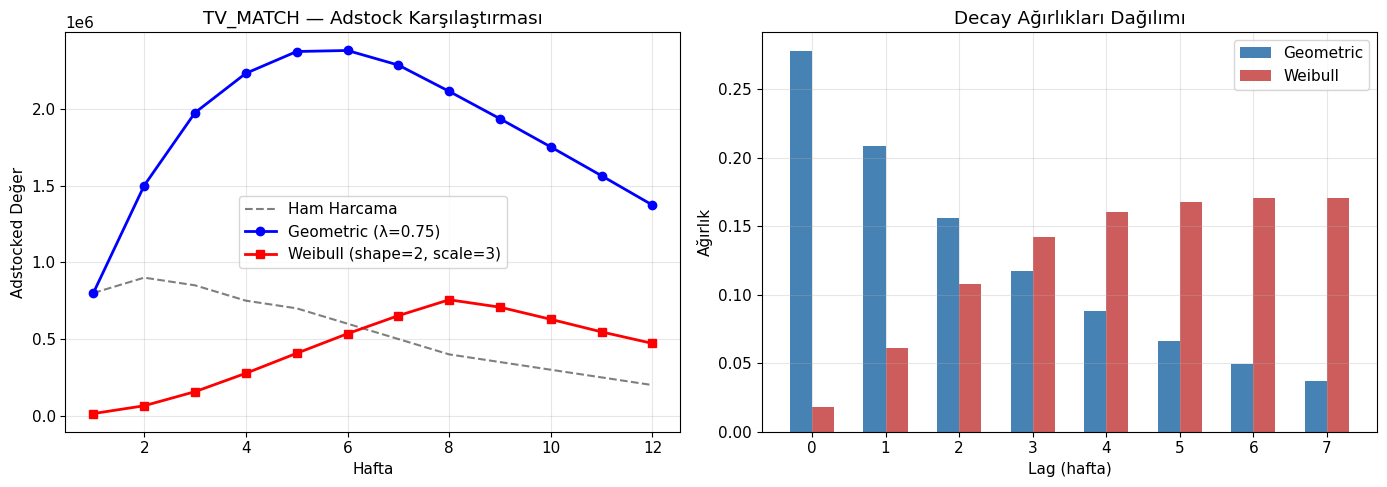


📊 Yorum:
- Geometric: Hemen zirve, monoton azalma. Kısa kampanyalarda iyi.
- Weibull: Gecikmeli zirve modelleyebilir. TV için daha gerçekçi.
- Geometric carry-over toplam: 22281828
- Weibull carry-over toplam: 5218012


In [3]:
def weibull_adstock(spend: list[float], shape: float, scale: float, max_lag: int = 8) -> list[float]:
    """Weibull CDF adstock (Robyn tarzı).
    
    Weibull CDF weights: w[l] = 1 - exp(-(l/scale)^shape)
    Her harcama, sonraki max_lag haftaya yayılır.
    """
    n = len(spend)
    adstocked = np.zeros(n)
    
    # Weibull CDF weights
    lags = np.arange(max_lag)
    weights = 1.0 - np.exp(-((lags + 1) / scale) ** shape)
    # Normalize
    weights = weights / weights.sum()
    
    for t in range(n):
        for l in range(min(max_lag, n - t)):
            adstocked[t + l] += spend[t] * weights[l]
    
    return adstocked.tolist()


# TV Match karşılaştırması
ch = 'tv_match'
spends = weekly_budgets[ch]

geo_adstock = compute_adstock(spends, ADSTOCK_PARAMS[ch])
weibull_ads = weibull_adstock(spends, shape=2.0, scale=3.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol: Adstock curves
weeks_x = np.arange(1, WEEKS + 1)
axes[0].plot(weeks_x, spends, 'k--', label='Ham Harcama', alpha=0.5)
axes[0].plot(weeks_x, geo_adstock, 'b-o', label=f'Geometric (λ={ADSTOCK_PARAMS[ch]})', linewidth=2)
axes[0].plot(weeks_x, weibull_ads, 'r-s', label='Weibull (shape=2, scale=3)', linewidth=2)
axes[0].set_xlabel('Hafta')
axes[0].set_ylabel('Adstocked Değer')
axes[0].set_title(f'{ch.upper()} — Adstock Karşılaştırması')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sağ: Decay weights
lags = np.arange(8)
geo_weights = [ADSTOCK_PARAMS[ch] ** l for l in lags]
geo_weights = [w / sum(geo_weights) for w in geo_weights]

weibull_w = 1.0 - np.exp(-((lags + 1) / 3.0) ** 2.0)
weibull_w = weibull_w / weibull_w.sum()

axes[1].bar(lags - 0.15, geo_weights, 0.3, label='Geometric', color='steelblue')
axes[1].bar(lags + 0.15, weibull_w, 0.3, label='Weibull', color='indianred')
axes[1].set_xlabel('Lag (hafta)')
axes[1].set_ylabel('Ağırlık')
axes[1].set_title('Decay Ağırlıkları Dağılımı')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Yorum:")
print("- Geometric: Hemen zirve, monoton azalma. Kısa kampanyalarda iyi.")
print("- Weibull: Gecikmeli zirve modelleyebilir. TV için daha gerçekçi.")
print(f"- Geometric carry-over toplam: {sum(geo_adstock):.0f}")
print(f"- Weibull carry-over toplam: {sum(weibull_ads):.0f}")

## 3. Regresyon Karşılaştırması: Deterministik vs Ridge

**Time's Hub:** `response = baseline + max_lift * saturation(adstock)` — parametreler sabit.  
**Robyn:** Ridge regression ile katsayılar veriden öğrenilir.

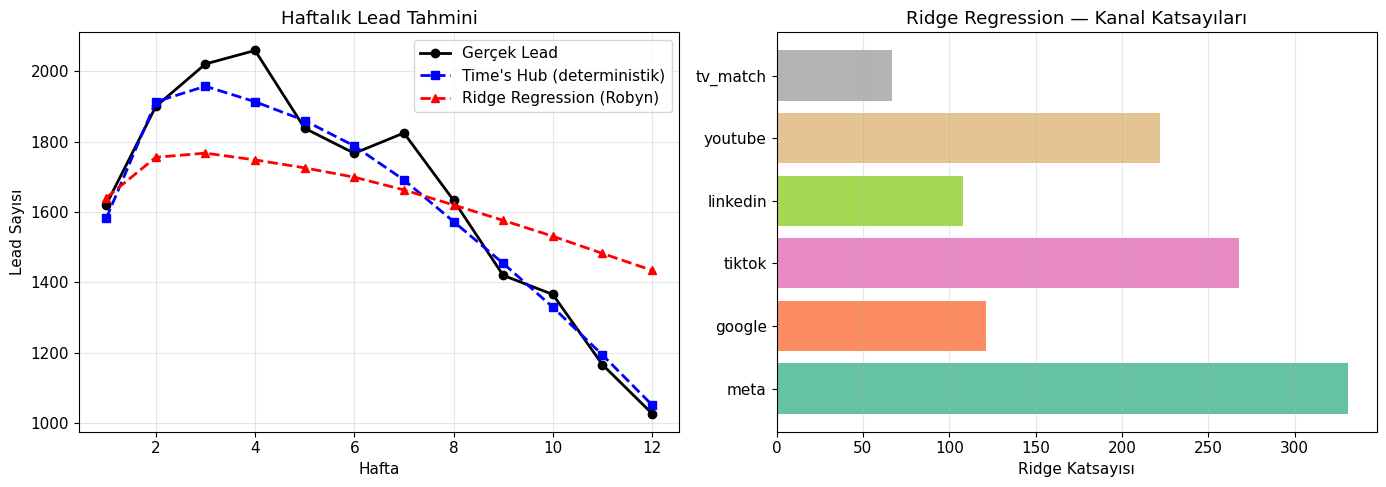


📊 Model Doğruluk Karşılaştırması:
  Time's Hub MAPE: 3.0%
  Ridge (Robyn)  MAPE: 12.2%
  Ridge intercept (baseline): 1175 vs Hub baseline: 120


In [4]:
from sklearn.linear_model import Ridge

# Time's Hub: deterministik tahmin
hub_predictions = []
for w in range(WEEKS):
    total = BASELINE_LEADS
    for ch, spends in weekly_budgets.items():
        decay = ADSTOCK_PARAMS[ch]
        alpha, gamma = SATURATION_PARAMS[ch]
        adstocked = compute_adstock(spends[:w+1], decay)
        sat = compute_saturation(adstocked[-1], alpha, gamma)
        total += MAX_LIFT[ch] * sat
    hub_predictions.append(total)

hub_predictions = np.array(hub_predictions)

# Robyn tarzı: Ridge regression
# Feature matrix: her kanal için saturated adstock
X_features = np.zeros((WEEKS, len(weekly_budgets)))
channel_names = list(weekly_budgets.keys())

for j, ch in enumerate(channel_names):
    spends = weekly_budgets[ch]
    decay = ADSTOCK_PARAMS[ch]
    alpha, gamma = SATURATION_PARAMS[ch]
    for w in range(WEEKS):
        adstocked = compute_adstock(spends[:w+1], decay)
        X_features[w, j] = compute_saturation(adstocked[-1], alpha, gamma)

# Ridge fit (alpha=1.0 — L2 regularization)
ridge = Ridge(alpha=1.0, fit_intercept=True)
ridge.fit(X_features, true_leads)
ridge_predictions = ridge.predict(X_features)

# Karşılaştırma
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

weeks_x = np.arange(1, WEEKS + 1)

# Sol: Tahmin karşılaştırması
axes[0].plot(weeks_x, true_leads, 'ko-', label='Gerçek Lead', linewidth=2)
axes[0].plot(weeks_x, hub_predictions, 'b--s', label="Time's Hub (deterministik)", linewidth=2)
axes[0].plot(weeks_x, ridge_predictions, 'r--^', label='Ridge Regression (Robyn)', linewidth=2)
axes[0].set_xlabel('Hafta')
axes[0].set_ylabel('Lead Sayısı')
axes[0].set_title('Haftalık Lead Tahmini')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Sağ: Ridge katsayıları
colors = plt.cm.Set2(np.linspace(0, 1, len(channel_names)))
bars = axes[1].barh(channel_names, ridge.coef_, color=colors)
axes[1].axvline(x=0, color='k', linewidth=0.5)
axes[1].set_xlabel('Ridge Katsayısı')
axes[1].set_title('Ridge Regression — Kanal Katsayıları')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# MAPE hesapla
hub_mape = np.mean(np.abs((true_leads - hub_predictions) / true_leads)) * 100
ridge_mape = np.mean(np.abs((true_leads - ridge_predictions) / true_leads)) * 100

print(f"\n📊 Model Doğruluk Karşılaştırması:")
print(f"  Time's Hub MAPE: {hub_mape:.1f}%")
print(f"  Ridge (Robyn)  MAPE: {ridge_mape:.1f}%")
print(f"  Ridge intercept (baseline): {ridge.intercept_:.0f} vs Hub baseline: {BASELINE_LEADS:.0f}")

## 4. Kanal Katkı Decomposition Karşılaştırması

Her iki model altında kanal bazlı lead katkısını karşılaştırıyoruz.

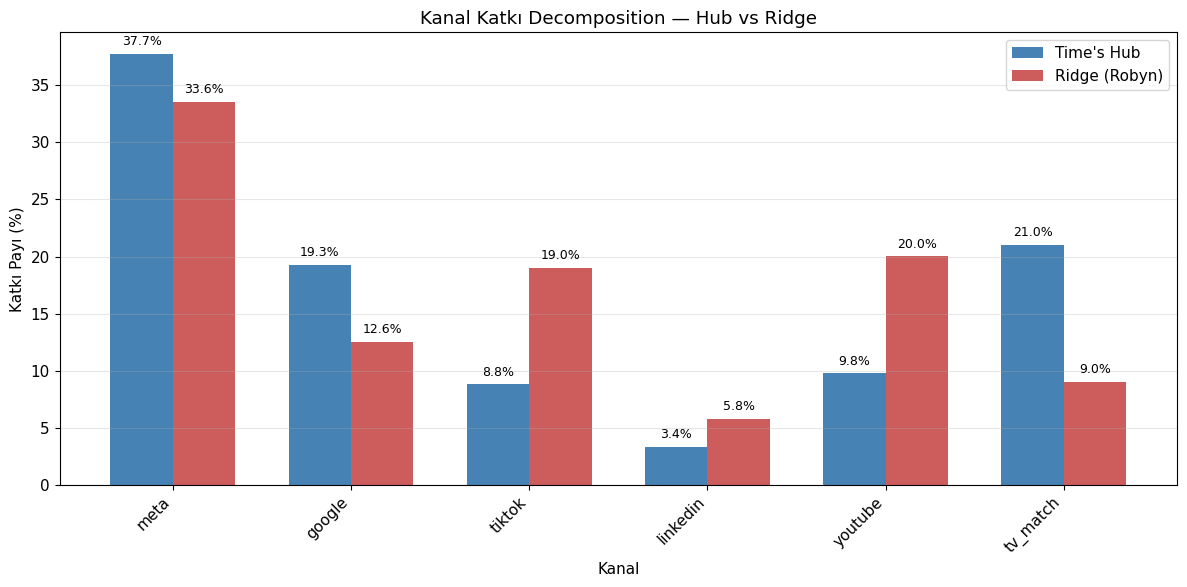


📊 Katkı Payı Karşılaştırması:
Kanal           Hub %  Ridge %     Fark
--------------------------------------
meta            37.7%    33.6%    -4.2%
google          19.3%    12.6%    -6.7%
tiktok           8.8%    19.0%   +10.2%
linkedin         3.4%     5.8%    +2.5%
youtube          9.8%    20.0%   +10.2%
tv_match        21.0%     9.0%   -12.0%


In [5]:
# Time's Hub decomposition
hub_contributions = {}
for ch in channel_names:
    spends = weekly_budgets[ch]
    decay = ADSTOCK_PARAMS[ch]
    alpha, gamma = SATURATION_PARAMS[ch]
    total_contrib = 0
    for w in range(WEEKS):
        adstocked = compute_adstock(spends[:w+1], decay)
        sat = compute_saturation(adstocked[-1], alpha, gamma)
        total_contrib += MAX_LIFT[ch] * sat
    hub_contributions[ch] = total_contrib

# Ridge decomposition: contribution = coefficient * sum(features)
ridge_contributions = {}
for j, ch in enumerate(channel_names):
    ridge_contributions[ch] = ridge.coef_[j] * X_features[:, j].sum()

# Normalize to percentages
hub_total = sum(hub_contributions.values())
ridge_total = sum(abs(v) for v in ridge_contributions.values())

hub_pct = {ch: v / hub_total * 100 for ch, v in hub_contributions.items()}
ridge_pct = {ch: abs(v) / ridge_total * 100 for ch, v in ridge_contributions.items()}

# Çift bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(channel_names))
width = 0.35

bars1 = ax.bar(x - width/2, [hub_pct[ch] for ch in channel_names], width,
               label="Time's Hub", color='steelblue')
bars2 = ax.bar(x + width/2, [ridge_pct[ch] for ch in channel_names], width,
               label='Ridge (Robyn)', color='indianred')

ax.set_xlabel('Kanal')
ax.set_ylabel('Katkı Payı (%)')
ax.set_title('Kanal Katkı Decomposition — Hub vs Ridge')
ax.set_xticks(x)
ax.set_xticklabels(channel_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Değer etiketleri
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=9)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.5, f'{h:.1f}%',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 Katkı Payı Karşılaştırması:")
print(f"{'Kanal':<12} {'Hub %':>8} {'Ridge %':>8} {'Fark':>8}")
print('-' * 38)
for ch in channel_names:
    diff = ridge_pct[ch] - hub_pct[ch]
    print(f"{ch:<12} {hub_pct[ch]:>7.1f}% {ridge_pct[ch]:>7.1f}% {diff:>+7.1f}%")

## 5. Parametre Optimizasyonu: Manual vs Nevergrad

Robyn, **Nevergrad** ile adstock + saturation parametrelerini otomatik optimize eder.  
Burada scipy.optimize ile benzer bir yaklaşım simüle ediyoruz.

In [6]:
def model_error(params, weekly_budgets, true_leads, channel_names):
    """Toplam modelin NRMSE'sini hesapla."""
    n_ch = len(channel_names)
    decays = params[:n_ch]
    lifts  = params[n_ch:2*n_ch]
    baseline = params[-1]
    
    predictions = np.zeros(WEEKS)
    for j, ch in enumerate(channel_names):
        spends = weekly_budgets[ch]
        alpha, gamma = SATURATION_PARAMS[ch]  # Saturation sabit tutalım
        for w in range(WEEKS):
            adstocked = compute_adstock(spends[:w+1], max(0.01, min(0.99, decays[j])))
            sat = compute_saturation(adstocked[-1], alpha, gamma)
            predictions[w] += abs(lifts[j]) * sat
    
    predictions += abs(baseline)
    residuals = true_leads - predictions
    nrmse = np.sqrt(np.mean(residuals**2)) / np.mean(true_leads)
    return nrmse


# Başlangıç: mevcut Hub parametreleri
n_ch = len(channel_names)
x0 = (
    [ADSTOCK_PARAMS[ch] for ch in channel_names] +
    [MAX_LIFT[ch] for ch in channel_names] +
    [BASELINE_LEADS]
)

# Sınırlar
bounds = (
    [(0.01, 0.99)] * n_ch +   # decays
    [(10, 5000)] * n_ch +      # max_lift
    [(0, 500)]                  # baseline
)

# Optimize
result = minimize(model_error, x0, args=(weekly_budgets, true_leads, channel_names),
                  method='L-BFGS-B', bounds=bounds)

opt_decays = result.x[:n_ch]
opt_lifts = result.x[n_ch:2*n_ch]
opt_baseline = result.x[-1]

print("📊 Parametre Optimizasyonu Sonuçları:")
print(f"\nOptimizer NRMSE: {result.fun:.4f} ({result.fun*100:.2f}%)")
print(f"\n{'Kanal':<12} {'Hub λ':>8} {'Opt λ':>8} {'Hub Lift':>10} {'Opt Lift':>10}")
print('-' * 52)
for j, ch in enumerate(channel_names):
    print(f"{ch:<12} {ADSTOCK_PARAMS[ch]:>8.2f} {opt_decays[j]:>8.2f} "
          f"{MAX_LIFT[ch]:>10.0f} {abs(opt_lifts[j]):>10.0f}")
print(f"\nBaseline: Hub={BASELINE_LEADS:.0f}, Optimized={abs(opt_baseline):.0f}")

📊 Parametre Optimizasyonu Sonuçları:

Optimizer NRMSE: 0.0331 (3.31%)

Kanal           Hub λ    Opt λ   Hub Lift   Opt Lift
----------------------------------------------------
meta             0.35     0.42       1200       1208
google           0.10     0.01        600        606
tiktok           0.30     0.46        400        406
linkedin         0.25     0.48        200        203
youtube          0.40     0.47        350        355
tv_match         0.75     0.47        500        506

Baseline: Hub=120, Optimized=130


## 6. Bütçe Reallocation Karşılaştırması

Her iki modelin kanal katkısına göre bütçe önerisi.

Kanal                Mevcut    Hub Önerisi  Ridge Önerisi        Hub Δ      Ridge Δ
meta           19,400,000₺   14,512,435₺   12,900,283₺  -4,887,565₺  -6,499,717₺
google          3,110,000₺    7,413,286₺    4,826,293₺  +4,303,286₺  +1,716,293₺
tiktok          3,760,000₺    3,389,232₺    7,316,311₺    -370,768₺  +3,556,311₺
linkedin        1,980,000₺    1,289,789₺    2,237,238₺    -690,211₺    +257,238₺
youtube         3,600,000₺    3,763,939₺    7,696,313₺    +163,939₺  +4,096,313₺
tv_match        6,600,000₺    8,081,319₺    3,473,562₺  +1,481,319₺  -3,126,438₺
TOPLAM         38,450,000₺   38,450,000₺   38,450,000₺


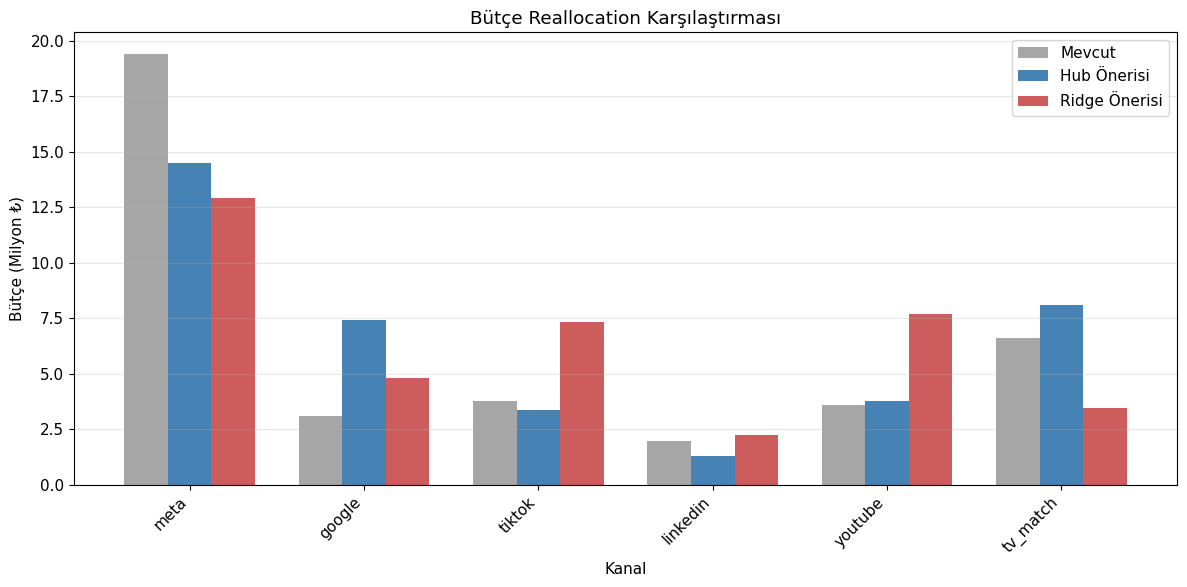

In [7]:
# Mevcut toplam bütçeler
current_budgets = {ch: sum(weekly_budgets[ch]) for ch in channel_names}
total_budget = sum(current_budgets.values())

# Hub-based reallocation (katkı payına göre)
hub_suggested = {ch: total_budget * (hub_pct[ch] / 100) for ch in channel_names}

# Ridge-based reallocation
ridge_suggested = {ch: total_budget * (ridge_pct[ch] / 100) for ch in channel_names}

# Tablo
print(f"{'Kanal':<12} {'Mevcut':>14} {'Hub Önerisi':>14} {'Ridge Önerisi':>14} {'Hub Δ':>12} {'Ridge Δ':>12}")
print('=' * 80)
for ch in channel_names:
    hub_d = hub_suggested[ch] - current_budgets[ch]
    ridge_d = ridge_suggested[ch] - current_budgets[ch]
    print(f"{ch:<12} {current_budgets[ch]:>12,.0f}₺ {hub_suggested[ch]:>12,.0f}₺ "
          f"{ridge_suggested[ch]:>12,.0f}₺ {hub_d:>+11,.0f}₺ {ridge_d:>+11,.0f}₺")
print('=' * 80)
print(f"{'TOPLAM':<12} {total_budget:>12,.0f}₺ {sum(hub_suggested.values()):>12,.0f}₺ "
      f"{sum(ridge_suggested.values()):>12,.0f}₺")

# Görselleştirme
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(channel_names))
width = 0.25

ax.bar(x - width, [current_budgets[ch] / 1e6 for ch in channel_names], width,
       label='Mevcut', color='gray', alpha=0.7)
ax.bar(x, [hub_suggested[ch] / 1e6 for ch in channel_names], width,
       label="Hub Önerisi", color='steelblue')
ax.bar(x + width, [ridge_suggested[ch] / 1e6 for ch in channel_names], width,
       label='Ridge Önerisi', color='indianred')

ax.set_xlabel('Kanal')
ax.set_ylabel('Bütçe (Milyon ₺)')
ax.set_title('Bütçe Reallocation Karşılaştırması')
ax.set_xticks(x)
ax.set_xticklabels(channel_names, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Sonuç ve Öneriler

### Karşılaştırma Özeti

| Kriter | Time's Hub | Robyn Yaklaşımı | Kazanan |
|--------|-----------|-----------------|--------|
| **Kurulum hızı** | Dakikalar (params config.py'de) | Saatler (R ortamı + tuning) | Hub |
| **Veri ihtiyacı** | 6-8 hafta yeterli | 2+ yıl ideal | Hub (PO Filo = 12 hafta) |
| **Adstock** | Geometric — basit, yeterli | Weibull — daha esnek | Robyn (TV için) |
| **Regresyon** | Deterministik — overfitting riski yok | Ridge — veriden öğrenir | Robyn (yeterli veri varsa) |
| **Offline kanallar** | GRP pipeline var | GRP desteği sınırlı | Hub |
| **Segment desteği** | S1-S4 segment bazlı analiz | Segment desteği yok | Hub |
| **MTA entegrasyonu** | DDA + Shapley + Markov | Sadece MMM | Hub |
| **Parametre güvenilirliği** | Uzman bilgisi + kalibrasyon | İstatistiksel optimizasyon | Robyn |

### Roadmap Önerileri

1. **Kısa vade:** Weibull adstock opsiyonunu Hub'a ekle (özellikle TV kanalları için)
2. **Orta vade:** Ridge regression'ı alternatif response model olarak entegre et
3. **Uzun vade:** Bayesian regression (PyMC) ile tam güven aralığı desteği
4. **Değişmeyen:** Segment desteği ve DDA hibrit framework Hub'ın ana avantajı

In [8]:
# Final özet metrikleri
print("=" * 60)
print("  TIME'S HUB vs ROBYN — FINAL KARSILASTIRMA")
print("=" * 60)
print(f"")
print(f"  Model Fit (MAPE):")
print(f"    Hub Deterministik : {hub_mape:.1f}%")
print(f"    Ridge (Robyn)     : {ridge_mape:.1f}%")
print(f"")
print(f"  Optimizer NRMSE     : {result.fun*100:.2f}%")
print(f"")
print(f"  Hub Avantajları:")
print(f"    - Segment bazlı analiz (S1-S4)")
print(f"    - Offline GRP pipeline")
print(f"    - DDA + MTA hibrit attribution")
print(f"    - Az veri ile çalışır (12 hafta)")
print(f"")
print(f"  Robyn Avantajları:")
print(f"    - Weibull adstock (gecikmeli etki)")
print(f"    - Ridge regression (veri-odaklı)")
print(f"    - Otomatik parametre optimizasyonu")
print(f"    - Prophet trend/seasonality")
print(f"")
print(f"  SONUC: PO Filo kampanyası icin Hub daha uygun.")
print(f"  Robyn'in istatistiksel gucunu roadmap'e ekle.")
print("=" * 60)

  TIME'S HUB vs ROBYN — FINAL KARSILASTIRMA

  Model Fit (MAPE):
    Hub Deterministik : 3.0%
    Ridge (Robyn)     : 12.2%

  Optimizer NRMSE     : 3.31%

  Hub Avantajları:
    - Segment bazlı analiz (S1-S4)
    - Offline GRP pipeline
    - DDA + MTA hibrit attribution
    - Az veri ile çalışır (12 hafta)

  Robyn Avantajları:
    - Weibull adstock (gecikmeli etki)
    - Ridge regression (veri-odaklı)
    - Otomatik parametre optimizasyonu
    - Prophet trend/seasonality

  SONUC: PO Filo kampanyası icin Hub daha uygun.
  Robyn'in istatistiksel gucunu roadmap'e ekle.
